# Differential vs Cumulative — One Duality Across Physical Science

A *differential* quantity is **local / intensive** — how much per unit something:
a probability density $p(x)$, a cross section per solid angle $d\sigma/d\Omega$, a spectral
density $S(f)$. Its *cumulative* partner is **global / extensive** — the running total:
a CDF $F(x)=\int_{-\infty}^{x}p$, an integrated cross section, the energy up to a frequency.

The two are linked by the only theorem that matters here, the **fundamental theorem of calculus**:

$$\text{cumulative}(x) = \int^{x} \text{differential},\qquad
\text{differential}(x) = \frac{d}{dx}\,\text{cumulative}(x).$$

And this is *literally* the Dirac-$\delta$ / Heaviside-$\theta$ pair from
`griffiths_ch1_solutions.ipynb` §9: $\theta(x)=\int_{-\infty}^{x}\delta$, $\;\delta(x)=\theta'(x)$.
A CDF is the $\theta$ of its PDF. We ride that one idea through probability, scattering, and spectra.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Math

import griffiths as gr
sp.init_printing(use_latex="mathjax")
rng = np.random.default_rng(2026)

## §1 The pair: $\delta \leftrightarrow \theta$ is differential $\leftrightarrow$ cumulative

The point spike $\delta$ is the differential of the step $\theta$; the step is the cumulative of
the spike. Every PDF/CDF, $d\sigma/d\Omega$/$\sigma$, $S(f)$/$E(f)$ below is a smeared-out version
of exactly this pair.

<IPython.core.display.Math object>

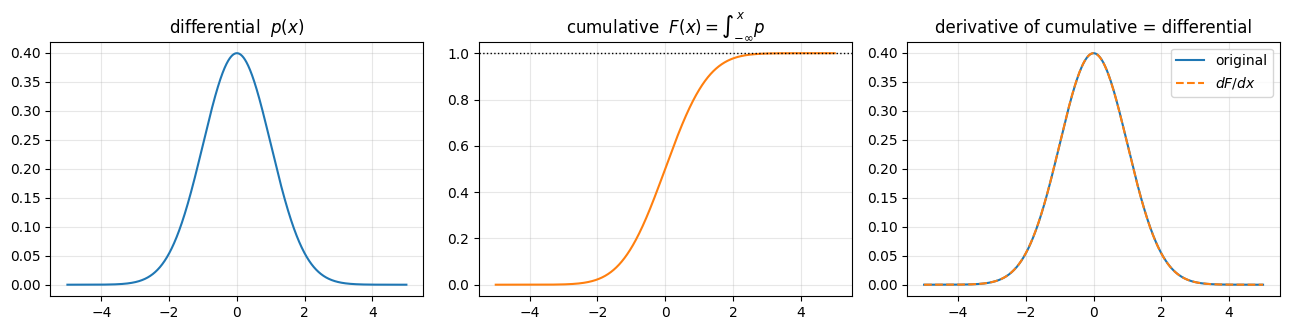

round-trip max error: 6.05e-04  (FTC, numerically)


In [2]:
x = gr.deltas.x if hasattr(gr.deltas, "x") else sp.Symbol("x", real=True)
display(Math(r"\theta(x) = " + sp.latex(gr.step()) + r"\quad\text{(cumulative)}"
             r",\qquad \frac{d\theta}{dx} = " + sp.latex(gr.d_step_dx())
             + r"\quad\text{(differential)}"))

# numeric round trip on a smooth bump: differentiate the cumulative, integrate the differential
xs = np.linspace(-5, 5, 2000)
dx = xs[1] - xs[0]
pdf = np.exp(-xs**2 / 2) / np.sqrt(2*np.pi)        # differential (a density)
cdf = np.cumsum(pdf) * dx                           # cumulative = running integral
pdf_back = np.gradient(cdf, xs)                      # differential = derivative of cumulative

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].plot(xs, pdf); ax[0].set_title(r"differential  $p(x)$")
ax[1].plot(xs, cdf, "C1"); ax[1].set_title(r"cumulative  $F(x)=\int_{-\infty}^x p$")
ax[1].axhline(1, ls=":", c="k", lw=1)
ax[2].plot(xs, pdf, label="original"); ax[2].plot(xs, pdf_back, "--", label=r"$dF/dx$")
ax[2].set_title("derivative of cumulative = differential"); ax[2].legend()
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"round-trip max error: {np.max(np.abs(pdf - pdf_back)):.2e}  (FTC, numerically)")

## §2 Probability: PDF, CDF, and the *complementary* cumulative (the rare-event view)

Three views of one distribution:

- **differential** — PDF $p(x)$, the shape
- **cumulative** — CDF $F(x)=P(X\le x)$, "how much mass so far"
- **complementary cumulative** — CCDF $\bar F(x)=1-F(x)=P(X>x)$, the **survival / exceedance**
  function. This is the one a rare-event detector actually uses: a rogue wave is *defined* by
  exceedance, $H > 2H_s$, so the tail of $\bar F$ is the whole game.

We contrast a Gaussian sea with a heavy-tailed one. On a log axis the CCDF exposes what the PDF
hides: how fucked the tail is.

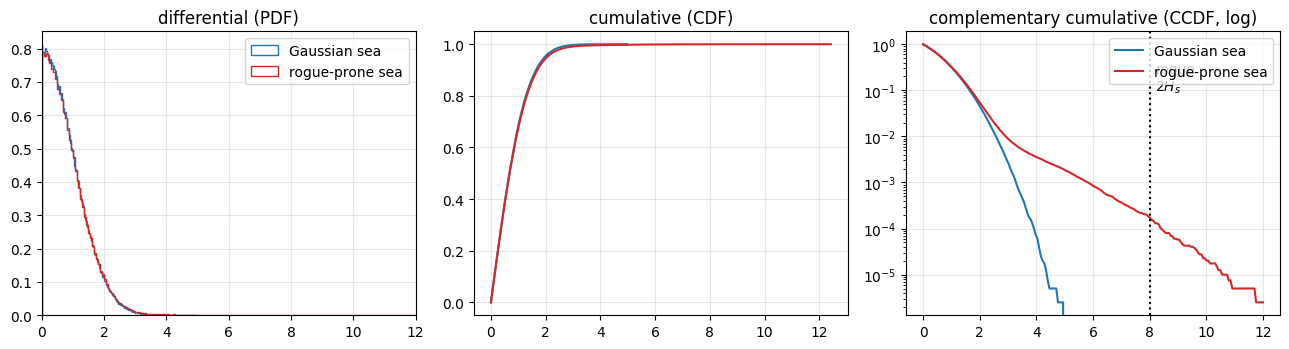

P(rogue) Gaussian sea : < 1/N (none observed)
P(rogue) heavy tail   : 1.72e-04   (~1 in 5,797)
Same PDFs look nearly identical near the mean; the CCDF tail is where the
rogue risk -- and the class imbalance the RogueGuard CNN faces -- actually lives.


In [3]:
# significant wave height H_s ~ 4*sigma; rogue threshold = 2 H_s (abnormality index)
N = 400_000
sigma = 1.0
gauss = np.abs(rng.normal(0, sigma, N))                       # Rayleigh-distributed amplitudes
# a heavier tail: occasional nonlinear focusing events (mixture)
heavy = gauss.copy()
hit = rng.random(N) < 0.02
heavy[hit] = np.abs(rng.normal(0, 3*sigma, hit.sum()))        # rogue-prone sea

Hs = 4*sigma
rogue = 2*Hs

def ccdf(data, grid):
    # complementary CDF P(X > x): fraction of samples exceeding each grid value
    return np.array([(data > g).mean() for g in grid])

grid = np.linspace(0, 12, 200)
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
for d, lab, c in [(gauss, "Gaussian sea", "C0"), (heavy, "rogue-prone sea", "C3")]:
    ax[0].hist(d, bins=200, density=True, histtype="step", color=c, label=lab)       # differential
    xs2 = np.sort(d); F = np.arange(1, N+1)/N
    ax[1].plot(xs2, F, color=c)                                                       # cumulative
    ax[2].semilogy(grid, ccdf(d, grid), color=c, label=lab)                          # complementary
ax[0].set_title("differential (PDF)"); ax[0].legend(); ax[0].set_xlim(0, 12)
ax[1].set_title("cumulative (CDF)")
ax[2].set_title("complementary cumulative (CCDF, log)")
ax[2].axvline(rogue, ls=":", c="k"); ax[2].text(rogue+0.2, 1e-1, "rogue\n$2H_s$")
ax[2].legend()
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

p_g = (gauss > rogue).mean(); p_h = (heavy > rogue).mean()
print(f"P(rogue) Gaussian sea : {p_g:.2e}   (~1 in {1/p_g:,.0f})" if p_g else
      "P(rogue) Gaussian sea : < 1/N (none observed)")
print(f"P(rogue) heavy tail   : {p_h:.2e}   (~1 in {1/p_h:,.0f})")
print("Same PDFs look nearly identical near the mean; the CCDF tail is where the")
print("rogue risk -- and the class imbalance the RogueGuard CNN faces -- actually lives.")

## §3 Scattering: differential cross section $d\sigma/d\Omega$ vs total $\sigma$

Rayleigh scattering (the SEALS Project-1 physics) has the angular differential cross section

$$\frac{d\sigma}{d\Omega} \propto 1 + \cos^2\theta .$$

The **differential** form tells you where the light goes; the **cumulative** form — integrate over
solid angle — gives the total cross section $\sigma=\int (d\sigma/d\Omega)\,d\Omega$ and the
fraction of power scattered within angle $\theta$. Forward and backward lobes are equal; the
running integral makes that quantitative.

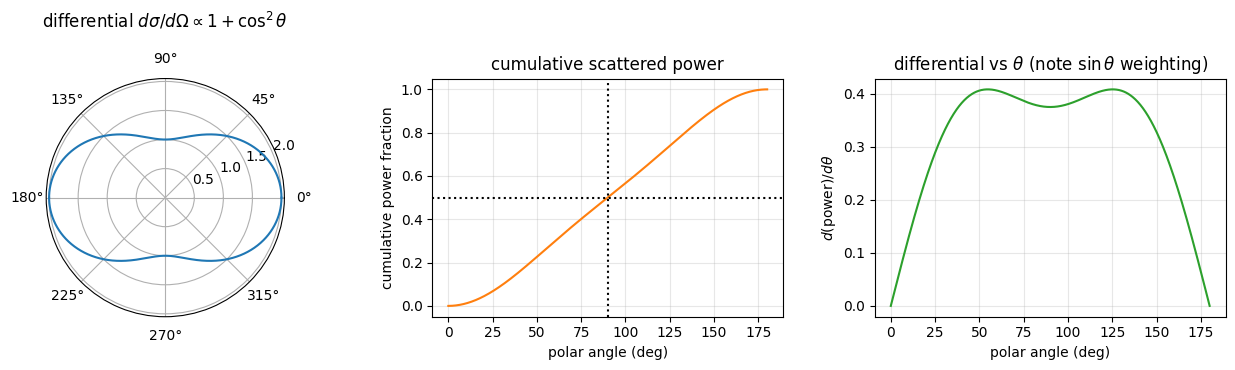

total cross section (numeric / analytic): 16.7551 / 16.7552  ratio 1.0000
half the power is scattered within 89.9 deg  (90 deg by symmetry -- forward and backward lobes are equal)


In [4]:
theta = np.linspace(0, np.pi, 1000)
dsig = 1 + np.cos(theta)**2                        # differential (per solid angle), up to a constant

# cumulative fraction within polar angle theta:  integral of dsig * 2pi sin(theta) dtheta
weight = dsig * 2*np.pi*np.sin(theta)
cum = np.cumsum(weight) * (theta[1]-theta[0])
total_num = cum[-1]
total_ana = (16*np.pi/3)                           # analytic: 2pi * int_0^pi (1+cos^2)sin dtheta = 2pi*8/3
cum_frac = cum / total_num

fig = plt.figure(figsize=(13, 3.8))
axp = fig.add_subplot(1, 3, 1, projection="polar")
axp.plot(theta, dsig); axp.plot(-theta, dsig, "C0")
axp.set_title(r"differential $d\sigma/d\Omega\propto 1+\cos^2\theta$", pad=18)
ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(np.degrees(theta), cum_frac, "C1")
ax2.axhline(0.5, ls=":", c="k"); ax2.axvline(90, ls=":", c="k")
ax2.set_xlabel("polar angle (deg)"); ax2.set_ylabel("cumulative power fraction")
ax2.set_title("cumulative scattered power"); ax2.grid(alpha=0.3)
ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(np.degrees(theta), weight/total_num, "C2")
ax3.set_xlabel("polar angle (deg)"); ax3.set_ylabel(r"$d(\text{power})/d\theta$")
ax3.set_title(r"differential vs $\theta$ (note $\sin\theta$ weighting)"); ax3.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"total cross section (numeric / analytic): {total_num:.4f} / {total_ana:.4f}"
      f"  ratio {total_num/total_ana:.4f}")
print(f"half the power is scattered within {np.degrees(theta[np.argmin(np.abs(cum_frac-0.5))]):.1f} deg"
      "  (90 deg by symmetry -- forward and backward lobes are equal)")

## §4 Spectra: power spectral density vs cumulative energy

For a signal, the **differential** quantity is the power spectral density $S(f)=|X(f)|^2$
(energy per unit frequency); the **cumulative** quantity is the integrated energy
$E(f)=\int_0^f S$. Parseval ties the ends together — total energy is the same computed in time or
frequency — and the cumulative curve defines a clean **bandwidth** (where, say, 90% of the energy
has accumulated). Same FTC pair, now in frequency.

Parseval check  E_time=5970.0  E_freq=5970.0  ratio=1.000000
90% of the signal energy is below 180 Hz


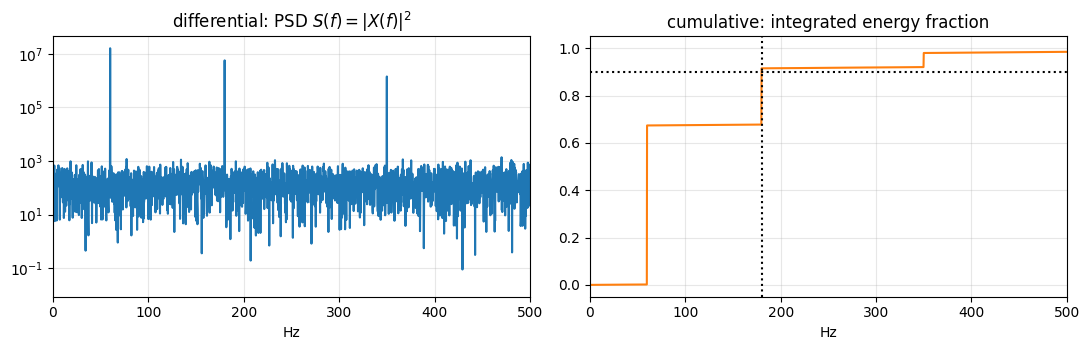

In [5]:
fs = 2000.0
t = np.arange(0, 4, 1/fs)
sig = (1.0*np.sin(2*np.pi*60*t) + 0.6*np.sin(2*np.pi*180*t)
       + 0.3*np.sin(2*np.pi*350*t) + 0.15*rng.standard_normal(t.size))

X = np.fft.rfft(sig); f = np.fft.rfftfreq(t.size, 1/fs)
psd = np.abs(X)**2                                    # differential: power spectral density
cum_energy = np.cumsum(psd) / np.sum(psd)             # cumulative energy fraction

# Parseval: time-domain energy == frequency-domain energy
E_time = np.sum(sig**2)
E_freq = np.sum(np.abs(np.fft.fft(sig))**2) / t.size
print(f"Parseval check  E_time={E_time:.1f}  E_freq={E_freq:.1f}  ratio={E_time/E_freq:.6f}")
bw90 = f[np.argmin(np.abs(cum_energy - 0.90))]
print(f"90% of the signal energy is below {bw90:.0f} Hz")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].semilogy(f, psd, "C0"); ax[0].set_xlim(0, 500)
ax[0].set_title(r"differential: PSD $S(f)=|X(f)|^2$"); ax[0].set_xlabel("Hz")
ax[1].plot(f, cum_energy, "C1"); ax[1].set_xlim(0, 500)
ax[1].axhline(0.9, ls=":", c="k"); ax[1].axvline(bw90, ls=":", c="k")
ax[1].set_title("cumulative: integrated energy fraction"); ax[1].set_xlabel("Hz")
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §5 The same table, three times

| domain | differential (local) | cumulative (global) | link |
|---|---|---|---|
| $\delta/\theta$ | $\delta(x)$ | $\theta(x)$ | $\theta'=\delta$ |
| probability | PDF $p(x)$ | CDF $F(x)$ (and CCDF $\bar F$) | $F'=p$ |
| scattering | $d\sigma/d\Omega$ | total $\sigma$, power-within-$\theta$ | $\sigma=\int d\sigma$ |
| spectra | PSD $S(f)$ | energy $E(f)$ | $E'=S$, Parseval |

**Why it matters in this repo:**
- The rogue-wave detector thresholds on the **complementary cumulative** tail, not the PDF — which
  is exactly why accuracy is a rotten metric and minority recall is the right one
  (`majority_imbalance_rotten_labels.ipynb`).
- SEALS scattering reports a **differential** cross section but power budgets need the **cumulative**
  integral over collection optics.
- "90% bandwidth" of the dispersed signal in `gs_core.py` is a cumulative-energy statement about a
  differential PSD.

Differential answers *where / how concentrated*; cumulative answers *how much by here*. Calculus is
just the elevator between the two floors — and it is the $\delta\!\leftrightarrow\!\theta$ elevator
every time.